In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shifa199/rice-leaf-and-crop-disease-detection-dataset/Tungro/orginal/20241114_150555.jpg
/kaggle/input/datasets/shifa199/rice-leaf-and-crop-disease-detection-dataset/Tungro/orginal/20241114_145527.jpg
/kaggle/input/datasets/shifa199/rice-leaf-and-crop-disease-detection-dataset/Tungro/orginal/IMG_20241114_144634.jpg
/kaggle/input/datasets/shifa199/rice-leaf-and-crop-disease-detection-dataset/Tungro/orginal/IMG_20241114_155701.jpg
/kaggle/input/datasets/shifa199/rice-leaf-and-crop-disease-detection-dataset/Tungro/orginal/IMG_20241114_154546.jpg
/kaggle/input/datasets/shifa199/rice-leaf-and-crop-disease-detection-dataset/Tungro/orginal/IMG_20241114_161614.jpg
/kaggle/input/datasets/shifa199/rice-leaf-and-crop-disease-detection-dataset/Tungro/orginal/20241114_150917.jpg
/kaggle/input/datasets/shifa199/rice-leaf-and-crop-disease-detection-dataset/Tungro/orginal/20241114_152001.jpg
/kaggle/input/datasets/shifa199/rice-leaf-and-crop-disease-detection-dataset/Tungro/orgi

In [2]:
!pip install -q grad-cam timm tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 81.9 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
import os, time, random, shutil, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import timm
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

from torchvision import datasets, transforms, models
from torchvision.models import (
    MobileNet_V3_Large_Weights,   # CHANGED: Large instead of Small
    EfficientNet_B0_Weights,
    ResNet18_Weights,
    DenseNet121_Weights
)
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

BASE_PATH = "/kaggle/input/datasets/shifa199/rice-leaf-and-crop-disease-detection-dataset"
DATASET   = BASE_PATH
FILTERED  = "/kaggle/working/filtered_dataset"
OUT_DIR   = "/kaggle/working/paper_outputs"
for sub in ["", "/plots", "/gradcam", "/checkpoints"]:
    os.makedirs(OUT_DIR + sub, exist_ok=True)
print("Dataset folders:", os.listdir(DATASET))

Device: cuda
GPU: Tesla T4
Dataset folders: ['Tungro', 'Rice Blast', 'Healthy _leaf', 'Bacterial Leaf Blight', 'Rice']


In [5]:
BATCH_SIZE         = 32
CNN_EPOCHS         = 20
DL_EPOCHS          = 20
TRANSFORMER_EPOCHS = 30
PATIENCE           = 7
print(f"Batch:{BATCH_SIZE} | CNN:{CNN_EPOCHS} | DL:{DL_EPOCHS} | Transformer:{TRANSFORMER_EPOCHS} | Patience:{PATIENCE}")

Batch:32 | CNN:20 | DL:20 | Transformer:30 | Patience:7


In [6]:
classes_keep = ["Bacterial Leaf Blight", "Rice Blast", "Tungro", "Healthy _leaf"]
if os.path.exists(FILTERED): shutil.rmtree(FILTERED)
os.makedirs(FILTERED, exist_ok=True)
for c in classes_keep:
    src = os.path.join(DATASET, c)
    if os.path.exists(src):
        shutil.copytree(src, os.path.join(FILTERED, c), dirs_exist_ok=True)
        print(f"Copied: {c}")
    else:
        print(f"Missing: {src}")

from pathlib import Path
total, counts = 0, {}
for cls in classes_keep:
    imgs = (list(Path(FILTERED,cls).rglob("*.jpg")) +
            list(Path(FILTERED,cls).rglob("*.jpeg")) +
            list(Path(FILTERED,cls).rglob("*.png")))
    counts[cls] = len(imgs); total += len(imgs)
    print(f"  {cls:<25} -> {len(imgs):>5}")
ratio = counts[max(counts,key=counts.get)] / counts[min(counts,key=counts.get)]
print(f"  TOTAL: {total}  |  Imbalance ratio: {ratio:.2f}x")


Copied: Bacterial Leaf Blight
Copied: Rice Blast
Copied: Tungro
Copied: Healthy _leaf
  Bacterial Leaf Blight     ->   978
  Rice Blast                ->  3343
  Tungro                    ->  3745
  Healthy _leaf             ->  1372
  TOTAL: 9438  |  Imbalance ratio: 3.83x


In [7]:
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.65, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02,0.15)),
])
test_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])


In [8]:
dataset_full = datasets.ImageFolder(FILTERED, transform=train_tf)
targets = np.array(dataset_full.targets)
indices = np.arange(len(targets))
train_idx, temp_idx = train_test_split(indices,  test_size=0.2, stratify=targets,        random_state=42)
val_idx,   test_idx = train_test_split(temp_idx, test_size=0.5, stratify=targets[temp_idx], random_state=42)

train_dataset = datasets.ImageFolder(FILTERED, transform=train_tf)
val_dataset   = datasets.ImageFolder(FILTERED, transform=test_tf)
test_dataset  = datasets.ImageFolder(FILTERED, transform=test_tf)

train_ds = Subset(train_dataset, train_idx)
val_ds   = Subset(val_dataset,   val_idx)
test_ds  = Subset(test_dataset,  test_idx)

class_names = train_dataset.classes
num_classes = len(class_names)
print("Classes:", class_names)
print(f"Train:{len(train_ds)} | Val:{len(val_ds)} | Test:{len(test_ds)}")


Classes: ['Bacterial Leaf Blight', 'Healthy _leaf', 'Rice Blast', 'Tungro']
Train:7550 | Val:944 | Test:944


In [9]:
train_targets = np.array([train_dataset.targets[i] for i in train_idx])
class_weights = compute_class_weight("balanced", classes=np.unique(train_targets), y=train_targets)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights_tensor)

sample_weights = torch.tensor([class_weights[t] for t in train_targets], dtype=torch.float)
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=(device=="cuda"))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=(device=="cuda"))
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=(device=="cuda"))

sampled = []
for i,(_, y) in enumerate(train_loader):
    sampled.extend(y.tolist())
    if i >= 100: break
c = Counter(sampled); total_s = sum(c.values())
print("Sampled distribution:")
for i, cls in enumerate(class_names):
    print(f"  {cls:<25} -> {c[i]:4d} ({c[i]/total_s:.3f})")


Class weights: tensor([2.4137, 1.7190, 0.7059, 0.6300], device='cuda:0')
Sampled distribution:
  Bacterial Leaf Blight     ->  802 (0.248)
  Healthy _leaf             ->  789 (0.244)
  Rice Blast                ->  827 (0.256)
  Tungro                    ->  814 (0.252)


In [10]:
def train_model(model, train_loader, val_loader, class_weights_tensor, device,
                epochs=15, lr=3e-4, weight_decay=1e-4,
                checkpoint_path="/kaggle/working/best.pth",
                optimizer_type="adamw", scheduler_type="cosine",
                model_name="Model", patience=7):

    model.to(device)
    loss_fn   = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
    optimizer = (optim.AdamW if optimizer_type=="adamw" else optim.Adam)(
                    model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = (torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
                 if scheduler_type=="cosine" else None)

    best_val_acc = 0.0; best_val_loss = float("inf"); no_improve = 0
    train_losses, val_losses = [], []
    print(f"\n{'='*60}\n  Training: {model_name}\n{'='*60}")

    for epoch in range(epochs):
        # ── Train
        model.train()
        run_loss = correct = total = 0
        bar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{epochs} [Train]", leave=False, ncols=85)
        for x, y in bar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            if out.dim()==4: out = out.mean(dim=[2,3])
            if out.dim()!=2: out = out.view(out.size(0),-1)
            loss = loss_fn(out, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            run_loss += loss.item(); correct += (out.argmax(1)==y).sum().item(); total += y.size(0)
            bar.set_postfix(loss=f"{loss.item():.4f}")

        epoch_loss = run_loss/len(train_loader); train_acc = correct/total
        train_losses.append(epoch_loss)

        # ── Validate
        model.eval(); v_correct = v_total = v_loss = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                if out.dim()==4: out = out.mean(dim=[2,3])
                if out.dim()!=2: out = out.view(out.size(0),-1)
                v_loss    += loss_fn(out, y).item()
                v_correct += (out.argmax(1)==y).sum().item(); v_total += y.size(0)

        val_acc  = v_correct/v_total; val_loss = v_loss/len(val_loader)
        val_losses.append(val_loss)
        if scheduler: scheduler.step()

        flag   = "✅" if val_acc > best_val_acc else "  "
        cur_lr = optimizer.param_groups[0]["lr"]
        print(f"  Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss:{epoch_loss:.4f} Acc:{train_acc:.4f} | "
              f"Val Loss:{val_loss:.4f} Acc:{val_acc:.4f} | "
              f"LR:{cur_lr:.2e} {flag}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), checkpoint_path)

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss; no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"\n  ⛔ Early stopping at epoch {epoch+1}"); break

    print(f"\n  Best Val Acc: {best_val_acc:.4f} — restored from checkpoint")
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    return model, train_losses, val_losses


def evaluate(model, loader, class_names, device):
    model.eval(); all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device); out = model(x)
            if out.dim()==4: out = out.mean(dim=[2,3])
            if out.dim()!=2: out = out.view(out.size(0),-1)
            all_preds.extend(out.argmax(1).cpu().numpy()); all_labels.extend(y.numpy())
    report = classification_report(all_labels, all_preds,
                 target_names=class_names, output_dict=True, zero_division=0)
    return all_labels, all_preds, report, confusion_matrix(all_labels, all_preds)


def model_info(model, device):
    model.eval()
    params  = sum(p.numel() for p in model.parameters())
    size_mb = params*4/(1024**2)
    x = torch.randn(1,3,224,224).to(device)
    with torch.inference_mode():
        for _ in range(10): model(x)
        if device=="cuda": torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(100): model(x)
        if device=="cuda": torch.cuda.synchronize()
        elapsed = time.perf_counter()-t0
    lat = elapsed/100
    return params, size_mb, lat, 1/lat


In [11]:
# ── MobileNetV3-Large
# CHANGE: Replaced MobileNetV3-Small (2.5M params, 67.7% ImageNet)
#         with MobileNetV3-Large (5.4M params, 74.0% ImageNet)
# WHY:    Small was architecturally too weak — val acc stuck at 41% across
#         multiple tuning attempts. Large has 2x the capacity and a stronger
#         feature extractor, while still being lightweight vs ResNet/DenseNet.
#
# FREEZE: Large has 17 feature layers (indices 0-16).
#         Freeze first 10, unfreeze last 7 (features[10:]).
#         This gives ~1.5M trainable params — enough to learn without overfitting.

model_mobilenet = models.mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.DEFAULT)

# Freeze first 10 of 17 feature layers
for i, layer in enumerate(model_mobilenet.features):
    for p in layer.parameters():
        p.requires_grad = (i >= 10)

# classifier[3] is the final linear layer in MobileNetV3-Large (same structure as Small)
in_feat = model_mobilenet.classifier[3].in_features
model_mobilenet.classifier[3] = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_feat, num_classes)
)

trainable = sum(p.numel() for p in model_mobilenet.parameters() if p.requires_grad)
print(f"MobileNetV3-Large — trainable params: {trainable:,}")

model_mobilenet, mobilenet_train_losses, mobilenet_val_losses = train_model(
    model_mobilenet, train_loader, val_loader, class_weights_tensor, device,
    epochs=CNN_EPOCHS, lr=3e-4, weight_decay=0.01,
    optimizer_type="adamw", scheduler_type="cosine",
    checkpoint_path=os.path.join(OUT_DIR,"checkpoints","mobilenet_best.pth"),
    model_name="MobileNetV3-Large", patience=PATIENCE
)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 193MB/s]


MobileNetV3-Large — trainable params: 4,047,204

  Training: MobileNetV3-Large


  Epoch 01/20 | Train Loss:0.7807 Acc:0.5862 | Val Loss:1.0782 Acc:0.4672 | LR:2.98e-04 ✅


  Epoch 02/20 | Train Loss:0.6124 Acc:0.7483 | Val Loss:0.7790 Acc:0.7807 | LR:2.93e-04 ✅


...

  Epoch 16/20 | Train Loss:0.4078 Acc:0.9416 | Val Loss:0.6141 Acc:0.9184 | LR:2.86e-05 ✅


  Epoch 17/20 | Train Loss:0.4170 Acc:0.9328 | Val Loss:0.6129 Acc:0.9121 | LR:1.63e-05   


  Epoch 18/20 | Train Loss:0.4112 Acc:0.9409 | Val Loss:0.6074 Acc:0.9174 | LR:7.34e-06   


  Epoch 19/20 | Train Loss:0.4059 Acc:0.9419 | Val Loss:0.6136 Acc:0.9184 | LR:1.85e-06   


  Epoch 20/20 | Train Loss:0.4065 Acc:0.9428 | Val Loss:0.6124 Acc:0.9174 | LR:0.00e+00   

  Best Val Acc: 0.9184 — restored from checkpoint


In [12]:
# ── EfficientNetB0
# Unfreeze features[6:] (last 3 of 9 blocks), Dropout 0.40
model_eff = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

for i, block in enumerate(model_eff.features):
    for p in block.parameters():
        p.requires_grad = (i >= 6)

in_feat = model_eff.classifier[1].in_features
model_eff.classifier[1] = nn.Sequential(
    nn.Dropout(p=0.40),
    nn.Linear(in_feat, num_classes)
)

trainable = sum(p.numel() for p in model_eff.parameters() if p.requires_grad)
print(f"EfficientNetB0 — trainable params: {trainable:,}")

model_eff, eff_train_losses, eff_val_losses = train_model(
    model_eff, train_loader, val_loader, class_weights_tensor, device,
    epochs=CNN_EPOCHS, lr=3e-4, weight_decay=0.01,
    optimizer_type="adamw", scheduler_type="cosine",
    checkpoint_path=os.path.join(OUT_DIR,"checkpoints","efficientnet_best.pth"),
    model_name="EfficientNetB0", patience=PATIENCE
)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 194MB/s]

EfficientNetB0 — trainable params: 3,160,864



  Training: EfficientNetB0


  Epoch 01/20 | Train Loss:0.8390 Acc:0.5420 | Val Loss:0.9905 Acc:0.5318 | LR:2.98e-04 ✅


...

  Epoch 16/20 | Train Loss:0.4790 Acc:0.8873 | Val Loss:0.6724 Acc:0.8941 | LR:2.86e-05   


  Epoch 17/20 | Train Loss:0.4733 Acc:0.8866 | Val Loss:0.6643 Acc:0.8951 | LR:1.63e-05 ✅


  Epoch 18/20 | Train Loss:0.4748 Acc:0.8921 | Val Loss:0.6608 Acc:0.8930 | LR:7.34e-06   


  Epoch 19/20 | Train Loss:0.4647 Acc:0.8951 | Val Loss:0.6619 Acc:0.8983 | LR:1.85e-06 ✅


  Epoch 20/20 | Train Loss:0.4617 Acc:0.9000 | Val Loss:0.6548 Acc:0.9004 | LR:0.00e+00 ✅

  Best Val Acc: 0.9004 — restored from checkpoint


In [13]:
# ── ResNet18
# Unfreeze all of layer4 (both blocks), weight_decay 0.02
model_resnet = models.resnet18(weights=ResNet18_Weights.DEFAULT)

for name, p in model_resnet.named_parameters():
    p.requires_grad = (name.startswith("layer4") or name.startswith("fc"))

in_feat = model_resnet.fc.in_features
model_resnet.fc = nn.Sequential(
    nn.BatchNorm1d(in_feat),
    nn.Dropout(p=0.45),
    nn.Linear(in_feat, num_classes)
)

trainable = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
print(f"ResNet18 — trainable params: {trainable:,}")

model_resnet, resnet_train_losses, resnet_val_losses = train_model(
    model_resnet, train_loader, val_loader, class_weights_tensor, device,
    epochs=DL_EPOCHS, lr=3e-4, weight_decay=0.02,
    optimizer_type="adamw", scheduler_type="cosine",
    checkpoint_path=os.path.join(OUT_DIR,"checkpoints","resnet18_best.pth"),
    model_name="ResNet18", patience=PATIENCE
)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 219MB/s]


ResNet18 — trainable params: 8,396,804

  Training: ResNet18


  Epoch 01/20 | Train Loss:0.9422 Acc:0.5673 | Val Loss:1.0594 Acc:0.5593 | LR:2.98e-04 ✅


  Epoch 02/20 | Train Loss:0.7868 Acc:0.6211 | Val Loss:1.0517 Acc:0.5275 | LR:2.93e-04   


...

  Epoch 16/20 | Train Loss:0.5383 Acc:0.8356 | Val Loss:0.7413 Acc:0.8167 | LR:2.86e-05   


  Epoch 17/20 | Train Loss:0.5241 Acc:0.8518 | Val Loss:0.7315 Acc:0.8369 | LR:1.63e-05   


  Epoch 18/20 | Train Loss:0.5171 Acc:0.8485 | Val Loss:0.7231 Acc:0.8369 | LR:7.34e-06   


  Epoch 19/20 | Train Loss:0.5225 Acc:0.8437 | Val Loss:0.7259 Acc:0.8220 | LR:1.85e-06   


  Epoch 20/20 | Train Loss:0.5086 Acc:0.8576 | Val Loss:0.7264 Acc:0.8305 | LR:0.00e+00   

  Best Val Acc: 0.8400 — restored from checkpoint


In [14]:
# ── DenseNet121
# Unfreeze last 3 denselayers (14,15,16) + norm5, weight_decay 0.02
model_densenet = models.densenet121(weights=DenseNet121_Weights.DEFAULT)

for p in model_densenet.parameters():
    p.requires_grad = False

for name, p in model_densenet.named_parameters():
    if (any(f"denseblock4.denselayer{k}" in name for k in [14,15,16]) or
        "features.norm5" in name or name.startswith("classifier")):
        p.requires_grad = True

in_feat = model_densenet.classifier.in_features
model_densenet.classifier = nn.Sequential(
    nn.BatchNorm1d(in_feat),
    nn.Dropout(p=0.45),
    nn.Linear(in_feat, num_classes)
)

trainable = sum(p.numel() for p in model_densenet.parameters() if p.requires_grad)
print(f"DenseNet121 — trainable params: {trainable:,}")

model_densenet, densenet_train_losses, densenet_val_losses = train_model(
    model_densenet, train_loader, val_loader, class_weights_tensor, device,
    epochs=DL_EPOCHS, lr=3e-4, weight_decay=0.02,
    optimizer_type="adamw", scheduler_type="cosine",
    checkpoint_path=os.path.join(OUT_DIR,"checkpoints","densenet121_best.pth"),
    model_name="DenseNet121", patience=PATIENCE
)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 233MB/s]


DenseNet121 — trainable params: 493,956

  Training: DenseNet121


  Epoch 01/20 | Train Loss:0.9841 Acc:0.5122 | Val Loss:1.1509 Acc:0.4110 | LR:2.98e-04 ✅


  Epoch 02/20 | Train Loss:0.7897 Acc:0.6015 | Val Loss:0.9798 Acc:0.5879 | LR:2.93e-04 ✅


...

  Epoch 16/20 | Train Loss:0.5979 Acc:0.7849 | Val Loss:0.8408 Acc:0.7267 | LR:2.86e-05   


  Epoch 17/20 | Train Loss:0.5935 Acc:0.7770 | Val Loss:0.8295 Acc:0.7235 | LR:1.63e-05   


  Epoch 18/20 | Train Loss:0.5895 Acc:0.7832 | Val Loss:0.8198 Acc:0.7394 | LR:7.34e-06   


  Epoch 19/20 | Train Loss:0.6002 Acc:0.7824 | Val Loss:0.8128 Acc:0.7553 | LR:1.85e-06 ✅


  Epoch 20/20 | Train Loss:0.5904 Acc:0.7820 | Val Loss:0.8369 Acc:0.7214 | LR:0.00e+00   

  Best Val Acc: 0.7553 — restored from checkpoint


In [15]:
# ── ViT-Tiny
# Freeze only first 4 blocks, drop_path 0.10, lr 5e-5, weight_decay 0.05
model_vit = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=True, num_classes=num_classes,
    drop_path_rate=0.10,
    drop_rate=0.10
)

for i, block in enumerate(model_vit.blocks):
    for p in block.parameters():
        p.requires_grad = (i >= 4)

for p in model_vit.patch_embed.parameters():
    p.requires_grad = False

trainable = sum(p.numel() for p in model_vit.parameters() if p.requires_grad)
print(f"ViT-Tiny — trainable params: {trainable:,}")

model_vit, vit_train_losses, vit_val_losses = train_model(
    model_vit, train_loader, val_loader, class_weights_tensor, device,
    epochs=TRANSFORMER_EPOCHS, lr=5e-5, weight_decay=0.05,
    optimizer_type="adamw", scheduler_type="cosine",
    checkpoint_path=os.path.join(OUT_DIR,"checkpoints","vit_best.pth"),
    model_name="ViT-Tiny", patience=PATIENCE
)


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

ViT-Tiny — trainable params: 3,598,084

  Training: ViT-Tiny


  Epoch 01/30 | Train Loss:1.0088 Acc:0.4554 | Val Loss:1.0129 Acc:0.4883 | LR:4.99e-05 ✅


  Epoch 02/30 | Train Loss:0.7971 Acc:0.5850 | Val Loss:0.9367 Acc:0.5540 | LR:4.95e-05 ✅


  Epoch 03/30 | Train Loss:0.7364 Acc:0.6303 | Val Loss:0.8716 Acc:0.6356 | LR:4.88e-05 ✅


...

  Epoch 22/30 | Train Loss:0.5423 Acc:0.8171 | Val Loss:0.7032 Acc:0.8464 | LR:8.27e-06   


  Epoch 23/30 | Train Loss:0.5349 Acc:0.8164 | Val Loss:0.7046 Acc:0.8422 | LR:6.42e-06   


  Epoch 24/30 | Train Loss:0.5399 Acc:0.8213 | Val Loss:0.6973 Acc:0.8400 | LR:4.77e-06   


  Epoch 25/30 | Train Loss:0.5372 Acc:0.8256 | Val Loss:0.7148 Acc:0.8337 | LR:3.35e-06   


  Epoch 26/30 | Train Loss:0.5209 Acc:0.8315 | Val Loss:0.7035 Acc:0.8400 | LR:2.16e-06   

  ⛔ Early stopping at epoch 26

  Best Val Acc: 0.8559 — restored from checkpoint


In [16]:
# ── Cell 15 — Train Transformer: Swin-Tiny
class_weights_tensor = torch.tensor(
    compute_class_weight(
        class_weight="balanced",
        classes=np.arange(num_classes),
        y=np.array([train_dataset.targets[i] for i in train_idx])
    ),
    dtype=torch.float
).to(device)

model_swin_backbone = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=0,
    drop_path_rate=0.2
)

# ── NEW: Stage 0 + patch_embed freeze ──
for name, p in model_swin_backbone.named_parameters():
    if name.startswith("layers.0") or name.startswith("patch_embed"):
        p.requires_grad = False

in_features = model_swin_backbone.num_features

class SwinClassifier(nn.Module):
    def __init__(self, backbone, in_features, num_classes):
        super().__init__()
        self.backbone = backbone
        self.dropout  = nn.Dropout(p=0.4)
        self.fc       = nn.Linear(in_features, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        if x.dim() == 4:
            x = x.mean(dim=[2, 3])
        elif x.dim() == 3:
            x = x.mean(dim=1)
        x = self.dropout(x)
        return self.fc(x)

model_swin = SwinClassifier(model_swin_backbone, in_features, num_classes)
model_swin.to(device)

# ── verify ──
trainable = sum(p.numel() for p in model_swin.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in model_swin.parameters() if not p.requires_grad)
print(f"Trainable: {trainable:,}  |  Frozen: {frozen:,}")
# Expected → Trainable: ~22,600,000 | Frozen: ~4,900,000

with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224).to(device)
    out   = model_swin(dummy)
    print(f"Swin output shape: {out.shape}")

model_swin, swin_train_losses, swin_val_losses = train_model(
    model_swin, train_loader, val_loader,
    class_weights_tensor, device,
    epochs=TRANSFORMER_EPOCHS,
    lr=5e-5,
    weight_decay=0.05,
    optimizer_type="adamw",
    scheduler_type="cosine",
    checkpoint_path=os.path.join(OUT_DIR, "checkpoints", "swin_best.pth"),
    model_name="Swin-Tiny",
    patience=PATIENCE
)

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Trainable: 27,292,840  |  Frozen: 229,590
Swin output shape: torch.Size([2, 4])

  Training: Swin-Tiny


  Epoch 01/30 | Train Loss:0.8243 Acc:0.5429 | Val Loss:1.1849 Acc:0.4502 | LR:4.99e-05 ✅


  Epoch 02/30 | Train Loss:0.6539 Acc:0.7030 | Val Loss:0.9752 Acc:0.5731 | LR:4.95e-05 ✅


  Epoch 03/30 | Train Loss:0.6034 Acc:0.7626 | Val Loss:0.7857 Acc:0.7765 | LR:4.88e-05 ✅


...

  Epoch 23/30 | Train Loss:0.4106 Acc:0.9420 | Val Loss:0.6279 Acc:0.9131 | LR:6.42e-06   


  Epoch 24/30 | Train Loss:0.3981 Acc:0.9489 | Val Loss:0.6243 Acc:0.9153 | LR:4.77e-06 ✅


  Epoch 25/30 | Train Loss:0.4092 Acc:0.9430 | Val Loss:0.6157 Acc:0.9184 | LR:3.35e-06 ✅


  Epoch 26/30 | Train Loss:0.3998 Acc:0.9466 | Val Loss:0.6196 Acc:0.9153 | LR:2.16e-06   


  Epoch 27/30 | Train Loss:0.4007 Acc:0.9468 | Val Loss:0.6219 Acc:0.9153 | LR:1.22e-06   

  ⛔ Early stopping at epoch 27

  Best Val Acc: 0.9184 — restored from checkpoint


In [28]:
for name, p in model_swin_backbone.named_parameters():
    if not p.requires_grad:
        print(name)

patch_embed.proj.weight
patch_embed.proj.bias
patch_embed.norm.weight
patch_embed.norm.bias
layers.0.blocks.0.norm1.weight
layers.0.blocks.0.norm1.bias
layers.0.blocks.0.attn.relative_position_bias_table
layers.0.blocks.0.attn.qkv.weight
layers.0.blocks.0.attn.qkv.bias
layers.0.blocks.0.attn.proj.weight
layers.0.blocks.0.attn.proj.bias
layers.0.blocks.0.norm2.weight
layers.0.blocks.0.norm2.bias
layers.0.blocks.0.mlp.fc1.weight
layers.0.blocks.0.mlp.fc1.bias
layers.0.blocks.0.mlp.fc2.weight
layers.0.blocks.0.mlp.fc2.bias
layers.0.blocks.1.norm1.weight
layers.0.blocks.1.norm1.bias
layers.0.blocks.1.attn.relative_position_bias_table
layers.0.blocks.1.attn.qkv.weight
layers.0.blocks.1.attn.qkv.bias
layers.0.blocks.1.attn.proj.weight
layers.0.blocks.1.attn.proj.bias
layers.0.blocks.1.norm2.weight
layers.0.blocks.1.norm2.bias
layers.0.blocks.1.mlp.fc1.weight
layers.0.blocks.1.mlp.fc1.bias
layers.0.blocks.1.mlp.fc2.weight
layers.0.blocks.1.mlp.fc2.bias


In [29]:
all_models = {
    "MobileNetV3-Large": model_mobilenet,
    "EfficientNetB0":    model_eff,
    "ResNet18":          model_resnet,
    "DenseNet121":       model_densenet,
    "ViT-Tiny":          model_vit,
    "Swin-Tiny":         model_swin
}
all_reports, all_model_metrics = {}, {}

for name, model in all_models.items():
    print(f"\nEvaluating {name}...")
    labels, preds, report, cm     = evaluate(model, test_loader, class_names, device)
    params, size_mb, latency, fps = model_info(model, device)
    all_reports[name] = report
    all_model_metrics[name] = {
        "accuracy":           report["accuracy"],
        "precision_weighted": report["weighted avg"]["precision"],
        "recall_weighted":    report["weighted avg"]["recall"],
        "weighted_f1":        report["weighted avg"]["f1-score"],
        "macro_f1":           report["macro avg"]["f1-score"],
        "params_M":           round(params/1e6,2),
        "size_mb":            size_mb,
        "latency_ms":         latency*1000,
        "fps":                fps,
        "cm":                 cm
    }
    print(f"  Acc:{report['accuracy']:.4f} | W-F1:{report['weighted avg']['f1-score']:.4f} | "
          f"Params:{round(params/1e6,2)}M | Latency:{latency*1000:.2f}ms")

plot_models = list(all_models.keys())
summary_df = pd.DataFrame(all_model_metrics).T[[
    "accuracy","precision_weighted","recall_weighted","weighted_f1",
    "macro_f1","params_M","size_mb","latency_ms","fps"
]].loc[plot_models]
print("\n=== Summary Table ===")
display(summary_df)
summary_df.to_csv(os.path.join(OUT_DIR,"model_summary_results.csv"))



Evaluating MobileNetV3-Large...
  Acc:0.9333 | W-F1:0.9355 | Params:4.21M | Latency:6.39ms

Evaluating EfficientNetB0...
  Acc:0.9153 | W-F1:0.9185 | Params:4.01M | Latency:8.16ms

Evaluating ResNet18...
  Acc:0.8506 | W-F1:0.8539 | Params:11.18M | Latency:2.92ms

Evaluating DenseNet121...
  Acc:0.7669 | W-F1:0.7795 | Params:6.96M | Latency:14.86ms

Evaluating ViT-Tiny...
  Acc:0.8400 | W-F1:0.8468 | Params:5.53M | Latency:4.77ms

Evaluating Swin-Tiny...
  Acc:0.9333 | W-F1:0.9346 | Params:27.52M | Latency:10.46ms

=== Summary Table ===


,accuracy,precision_weighted,recall_weighted,weighted_f1,macro_f1,params_M,size_mb,latency_ms,fps
MobileNetV3-Large,0.933263,0.946479,0.933263,0.935473,0.916111,4.21,16.049026,6.388471,156.531973
EfficientNetB0,0.915254,0.934828,0.915254,0.918473,0.897521,4.01,15.307129,8.156276,122.604978
ResNet18,0.850636,0.877868,0.850636,0.853921,0.838832,11.18,42.646744,2.922693,342.150176
DenseNet121,0.766949,0.848836,0.766949,0.779469,0.758233,6.96,26.550308,14.857042,67.308147
ViT-Tiny,0.840042,0.877594,0.840042,0.846801,0.824108,5.53,21.07692,4.773254,209.5007
Swin-Tiny,0.933263,0.943558,0.933263,0.934569,0.919416,27.52,104.989738,10.463461,95.570673


Best model: MobileNetV3-Large  (Test Acc: 0.9333)

                       precision    recall  f1-score   support

Bacterial Leaf Blight       0.69      0.97      0.81        98
        Healthy _leaf       0.94      1.00      0.97       137
           Rice Blast       0.99      0.85      0.92       335
               Tungro       0.98      0.97      0.97       374

             accuracy                           0.93       944
            macro avg       0.90      0.95      0.92       944
         weighted avg       0.95      0.93      0.94       944


  saved -> /kaggle/working/paper_outputs/plots/confusion_matrix_best_MobileNetV3-Large.png


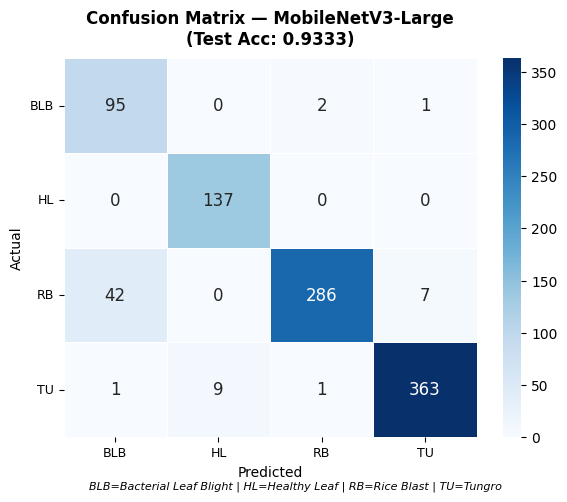

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# ── Identify best model
all_models = {
    "MobileNetV3-Large": model_mobilenet,
    "EfficientNetB0":    model_eff,
    "ResNet18":          model_resnet,
    "DenseNet121":       model_densenet,
    "ViT-Tiny":          model_vit,
    "Swin-Tiny":         model_swin,
}

best_name  = max(all_model_metrics, key=lambda k: all_model_metrics[k]["accuracy"])
best_model = all_models[best_name]
best_acc   = all_model_metrics[best_name]["accuracy"]
print(f"Best model: {best_name}  (Test Acc: {best_acc:.4f})")

# ── Re-evaluate on test set
best_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = best_model(x)
        if out.dim() == 4: out = out.mean(dim=[2,3])
        if out.dim() != 2: out = out.view(out.size(0), -1)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(y.numpy())

cm = confusion_matrix(all_labels, all_preds)
report = classification_report(all_labels, all_preds,
             target_names=class_names, zero_division=0)
print("\n" + report)

# ── Plot
short_labels = ["BLB", "HL", "RB", "TU"]
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_labels, yticklabels=short_labels,
            ax=ax, annot_kws={"size": 12}, linewidths=0.5)
ax.set_title(f"Confusion Matrix — {best_name}\n(Test Acc: {best_acc:.4f})",
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel("Predicted", fontsize=10)
ax.set_ylabel("Actual",    fontsize=10)
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9, rotation=0)
plt.figtext(0.5, 0.01,
    "BLB=Bacterial Leaf Blight | HL=Healthy Leaf | RB=Rice Blast | TU=Tungro",
    ha='center', fontsize=8, style='italic')
plt.tight_layout()
base = os.path.join(OUT_DIR, "plots", f"confusion_matrix_best_{best_name.replace(' ','_')}")
fig.savefig(base+".png", dpi=300, bbox_inches="tight")
fig.savefig(base+".pdf",           bbox_inches="tight")
print(f"\n  saved -> {base}.png")
plt.show()



                       precision    recall  f1-score   support

Bacterial Leaf Blight       0.72      0.97      0.83        98
        Healthy _leaf       0.94      1.00      0.97       137
           Rice Blast       0.99      0.85      0.92       335
               Tungro       0.96      0.97      0.97       374

             accuracy                           0.93       944
            macro avg       0.90      0.95      0.92       944
         weighted avg       0.94      0.93      0.93       944


  saved -> /kaggle/working/paper_outputs/plots/confusion_matrix_Swin-Tiny.png


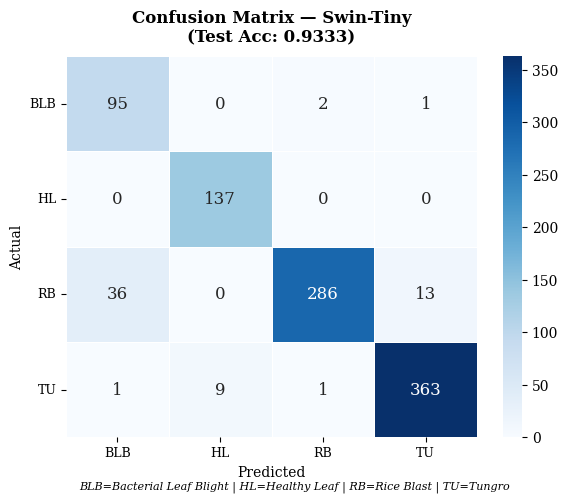

In [30]:
# ── Swin-Tiny Confusion Matrix ──
swin_name  = "Swin-Tiny"
swin_model = all_models[swin_name]
swin_acc   = all_model_metrics[swin_name]["accuracy"]

swin_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = swin_model(x)
        if out.dim() == 4: out = out.mean(dim=[2,3])
        if out.dim() != 2: out = out.view(out.size(0), -1)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(y.numpy())

cm_swin   = confusion_matrix(all_labels, all_preds)
report_swin = classification_report(all_labels, all_preds,
                target_names=class_names, zero_division=0)
print("\n" + report_swin)

# ── Plot ──
short_labels = ["BLB", "HL", "RB", "TU"]
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_swin, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_labels, yticklabels=short_labels,
            ax=ax, annot_kws={"size": 12}, linewidths=0.5)
ax.set_title(f"Confusion Matrix — {swin_name}\n(Test Acc: {swin_acc:.4f})",
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel("Predicted", fontsize=10)
ax.set_ylabel("Actual",    fontsize=10)
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9, rotation=0)
plt.figtext(0.5, 0.01,
    "BLB=Bacterial Leaf Blight | HL=Healthy Leaf | RB=Rice Blast | TU=Tungro",
    ha='center', fontsize=8, style='italic')
plt.tight_layout()
base = os.path.join(OUT_DIR, "plots", f"confusion_matrix_{swin_name.replace(' ','_')}")
fig.savefig(base+".png", dpi=300, bbox_inches="tight")
fig.savefig(base+".pdf",           bbox_inches="tight")
print(f"\n  saved -> {base}.png")
plt.show()

Generating Grad-CAM for: MobileNetV3-Large
Finding representative samples ...
Classes found: ['Bacterial Leaf Blight', 'Healthy _leaf', 'Rice Blast', 'Tungro']

  saved -> /kaggle/working/paper_outputs/gradcam/gradcam_best_MobileNetV3-Large.png


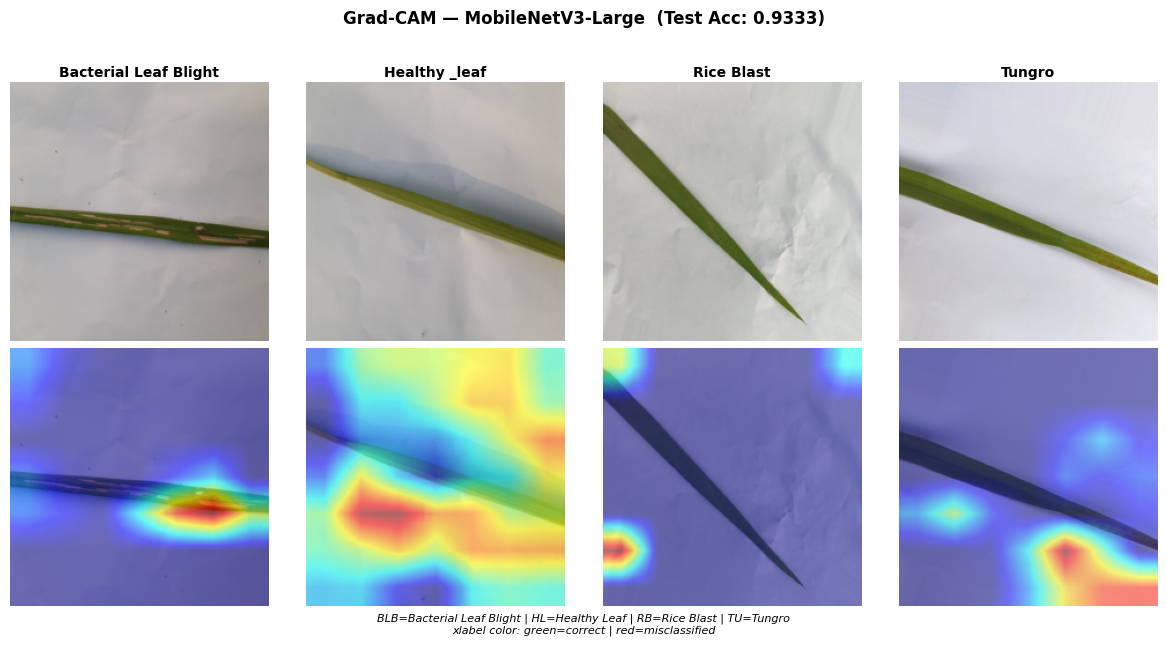


✅ Grad-CAM (best model) saved.


In [19]:
import os, math
import numpy as np
import torch
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# ── Normalization reverse (ImageNet)
inv_mean = np.array([0.485, 0.456, 0.406])
inv_std  = np.array([0.229, 0.224, 0.225])

def denormalize(t):
    img = t.permute(1, 2, 0).cpu().numpy()
    return np.clip(img * inv_std + inv_mean, 0, 1)

def get_pred(model, img):
    model.eval()
    with torch.no_grad():
        return model(img.unsqueeze(0).to(device)).argmax(1).item()

# ── ✅ FIX: Lazy evaluation using lambda
target_layers_map = {
    "MobileNetV3-Large": lambda m: [m.features[-2]],   # better than [-1]
    "EfficientNetB0":    lambda m: [m.features[-1]],
    "ResNet18":          lambda m: [m.layer4[-1]],
    "DenseNet121":       lambda m: [m.features[-1]],
    "ViT-Tiny":          lambda m: [m.blocks[-1].norm1],
    "Swin-Tiny":         lambda m: [m.backbone.norm],
}

# ── Reshape functions (for transformers)
def reshape_vit(tensor, H=14, W=14):
    tensor = tensor[:, 1:, :]
    return tensor.reshape(tensor.size(0), H, W, tensor.size(2)).permute(0,3,1,2)

def reshape_swin(tensor):
    if tensor.dim() == 4:
        return tensor.permute(0,3,1,2)
    B, L, C = tensor.shape
    H = W = int(math.sqrt(L))
    if H * W != L:
        return tensor.permute(0,2,1).unsqueeze(2)
    return tensor.reshape(B, H, W, C).permute(0,3,1,2)

reshape_map = {
    "ViT-Tiny":  reshape_vit,
    "Swin-Tiny": reshape_swin,
}

# ── Select correct target layer
target_layers = target_layers_map[best_name](best_model)

# ── Find 1 correct sample per class
print(f"Generating Grad-CAM for: {best_name}")
print("Finding representative samples ...")

best_model.eval()
seen = {}

for idx in range(len(test_ds)):
    img, label = test_ds[idx]

    if label in seen:
        continue

    if get_pred(best_model, img) == label:
        seen[label] = idx

    if len(seen) == num_classes:
        break

sample_indices = [seen[c] for c in sorted(seen.keys())]

print("Classes found:",
      [class_names[test_ds[i][1]] for i in sample_indices])

# ── Plot setup
n_cols = len(sample_indices)
fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 3, 6))

# ── Grad-CAM init
cam = GradCAM(
    model=best_model,
    target_layers=target_layers,
    reshape_transform=reshape_map.get(best_name, None)
)

# ── Generate visualizations
for ci, idx in enumerate(sample_indices):
    img, label = test_ds[idx]

    rgb  = denormalize(img)
    pred = get_pred(best_model, img)

    # Row 1: Original
    axes[0, ci].imshow(rgb)
    axes[0, ci].set_title(class_names[label],
                          fontsize=10,
                          fontweight='bold',
                          pad=4)
    axes[0, ci].axis('off')

    if ci == 0:
        axes[0, ci].set_ylabel("Original",
                               fontsize=9,
                               fontweight='bold')

    # Row 2: Grad-CAM
    grayscale = cam(
        input_tensor=img.unsqueeze(0).to(device),
        targets=[ClassifierOutputTarget(pred)]
    )[0]

    cam_img = show_cam_on_image(rgb, grayscale, use_rgb=True)

    axes[1, ci].imshow(cam_img)
    axes[1, ci].axis('off')

    color = 'green' if pred == label else 'red'

    axes[1, ci].set_xlabel(
        f"Pred: {class_names[pred]}",
        fontsize=9,
        color=color,
        fontweight='bold',
        labelpad=3
    )

    if ci == 0:
        axes[1, ci].set_ylabel("Grad-CAM",
                               fontsize=9,
                               fontweight='bold')

# ── Titles and saving
plt.suptitle(
    f"Grad-CAM — {best_name}",
    fontsize=12,
    fontweight='bold',
    y=1.02
)

plt.figtext(
    0.5, -0.02,
    "BLB=Bacterial Leaf Blight | HL=Healthy Leaf | RB=Rice Blast | TU=Tungro\n"
    "xlabel color: green=correct | red=misclassified",
    ha='center',
    fontsize=8,
    style='italic'
)

plt.tight_layout()

# ── Save output
base = os.path.join(
    OUT_DIR,
    "gradcam",
    f"gradcam_best_{best_name.replace(' ', '_')}"
)

os.makedirs(os.path.dirname(base), exist_ok=True)

fig.savefig(base + ".png", dpi=300, bbox_inches="tight")
fig.savefig(base + ".pdf", bbox_inches="tight")

print(f"\n  saved -> {base}.png")

plt.show()

print("\n✅ Grad-CAM (best model) saved.")

Generating Grad-CAM for: Swin-Tiny
Finding representative samples ...
Classes found: ['Bacterial Leaf Blight', 'Healthy _leaf', 'Rice Blast', 'Tungro']

  saved -> /kaggle/working/paper_outputs/gradcam/gradcam_Swin-Tiny.png


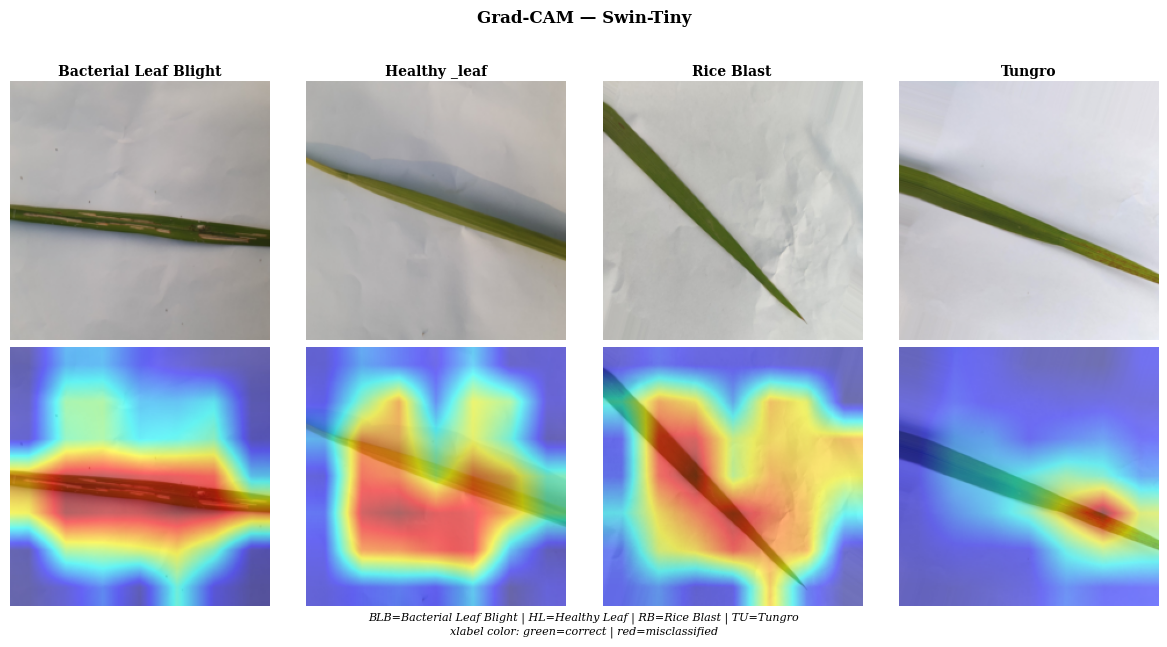


✅ Grad-CAM (Swin-Tiny) saved.


In [31]:
# ── Swin-Tiny Grad-CAM ──
swin_name  = "Swin-Tiny"
swin_model = all_models[swin_name]

target_layers_swin = target_layers_map[swin_name](swin_model)

print(f"Generating Grad-CAM for: {swin_name}")
print("Finding representative samples ...")

swin_model.eval()
seen = {}

for idx in range(len(test_ds)):
    img, label = test_ds[idx]
    if label in seen:
        continue
    if get_pred(swin_model, img) == label:
        seen[label] = idx
    if len(seen) == num_classes:
        break

sample_indices = [seen[c] for c in sorted(seen.keys())]
print("Classes found:", [class_names[test_ds[i][1]] for i in sample_indices])

# ── Plot setup
n_cols = len(sample_indices)
fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 3, 6))

# ── Grad-CAM init
cam_swin = GradCAM(
    model=swin_model,
    target_layers=target_layers_swin,
    reshape_transform=reshape_map.get(swin_name, None)
)

# ── Generate visualizations
for ci, idx in enumerate(sample_indices):
    img, label = test_ds[idx]
    rgb  = denormalize(img)
    pred = get_pred(swin_model, img)

    # Row 1: Original
    axes[0, ci].imshow(rgb)
    axes[0, ci].set_title(class_names[label], fontsize=10,
                          fontweight='bold', pad=4)
    axes[0, ci].axis('off')
    if ci == 0:
        axes[0, ci].set_ylabel("Original", fontsize=9, fontweight='bold')

    # Row 2: Grad-CAM
    grayscale = cam_swin(
        input_tensor=img.unsqueeze(0).to(device),
        targets=[ClassifierOutputTarget(pred)]
    )[0]

    cam_img = show_cam_on_image(rgb, grayscale, use_rgb=True)
    axes[1, ci].imshow(cam_img)
    axes[1, ci].axis('off')

    color = 'green' if pred == label else 'red'
    axes[1, ci].set_xlabel(f"Pred: {class_names[pred]}", fontsize=9,
                           color=color, fontweight='bold', labelpad=3)
    if ci == 0:
        axes[1, ci].set_ylabel("Grad-CAM", fontsize=9, fontweight='bold')

plt.suptitle(f"Grad-CAM — {swin_name}", fontsize=12,
             fontweight='bold', y=1.02)
plt.figtext(0.5, -0.02,
    "BLB=Bacterial Leaf Blight | HL=Healthy Leaf | RB=Rice Blast | TU=Tungro\n"
    "xlabel color: green=correct | red=misclassified",
    ha='center', fontsize=8, style='italic')
plt.tight_layout()

base = os.path.join(OUT_DIR, "gradcam",
                    f"gradcam_{swin_name.replace(' ', '_')}")
os.makedirs(os.path.dirname(base), exist_ok=True)
fig.savefig(base + ".png", dpi=300, bbox_inches="tight")
fig.savefig(base + ".pdf", bbox_inches="tight")
print(f"\n  saved -> {base}.png")
plt.show()
print("\n✅ Grad-CAM (Swin-Tiny) saved.")

Measuring latency (ms/image) ...
  MobileNetV3-Large    6.17 ms
  EfficientNetB0       8.20 ms
  ResNet18             2.67 ms
  DenseNet121          14.45 ms
  ViT-Tiny             4.62 ms
  Swin-Tiny            10.11 ms

  saved -> /kaggle/working/paper_outputs/plots/latency_all_models.png


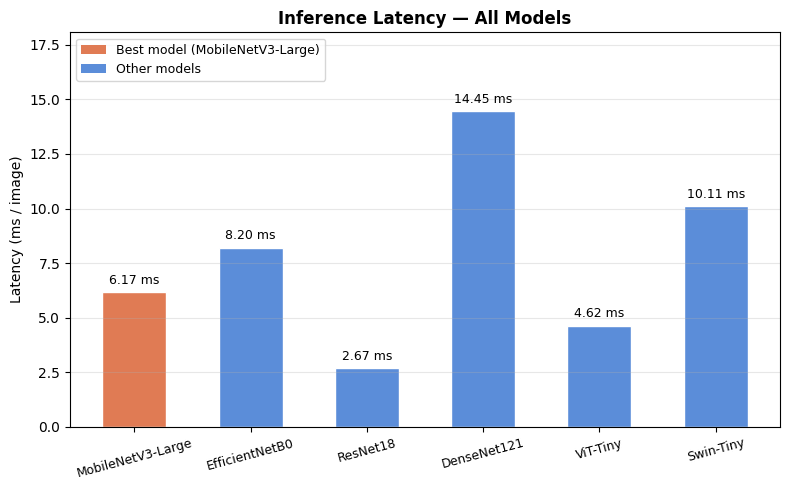


✅ Latency chart saved.


In [20]:
import time

# ── Measure latency for all models (100 forward passes, batch=1)
def measure_latency(model, device, n=100):
    model.eval()
    x = torch.randn(1, 3, 224, 224).to(device)
    with torch.inference_mode():
        for _ in range(10): model(x)          # warmup
        if device == "cuda": torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(n): model(x)
        if device == "cuda": torch.cuda.synchronize()
        elapsed = time.perf_counter() - t0
    return (elapsed / n) * 1000              # ms per image

model_names_ordered = [
    "MobileNetV3-Large", "EfficientNetB0", "ResNet18",
    "DenseNet121", "ViT-Tiny", "Swin-Tiny"
]
model_list = [
    model_mobilenet, model_eff, model_resnet,
    model_densenet,  model_vit, model_swin
]

latencies = []
print("Measuring latency (ms/image) ...")
for name, model in zip(model_names_ordered, model_list):
    lat = measure_latency(model, device)
    latencies.append(lat)
    print(f"  {name:<20} {lat:.2f} ms")

# ── Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e07b54' if n == best_name else '#5b8dd9' for n in model_names_ordered]
bars   = ax.bar(model_names_ordered, latencies, color=colors, width=0.55, edgecolor='white')
ax.bar_label(bars, fmt='%.2f ms', fontsize=9, padding=4)

# Highlight best model in legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e07b54', label=f'Best model ({best_name})'),
    Patch(facecolor='#5b8dd9', label='Other models')
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper left')

ax.set_ylabel("Latency (ms / image)", fontsize=10)
ax.set_title("Inference Latency — All Models", fontsize=12, fontweight='bold')
ax.set_ylim(0, max(latencies) * 1.25)
ax.tick_params(axis='x', rotation=15, labelsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

base = os.path.join(OUT_DIR, "plots", "latency_all_models")
fig.savefig(base+".png", dpi=300, bbox_inches="tight")
fig.savefig(base+".pdf",           bbox_inches="tight")
print(f"\n  saved -> {base}.png")
plt.show()
print("\n✅ Latency chart saved.")


Best model: MobileNetV3-Large
Correct: 3 | Incorrect: 3
✅ Saved -> /kaggle/working/paper_outputs/plots/qualitative_table_publication.png / .pdf


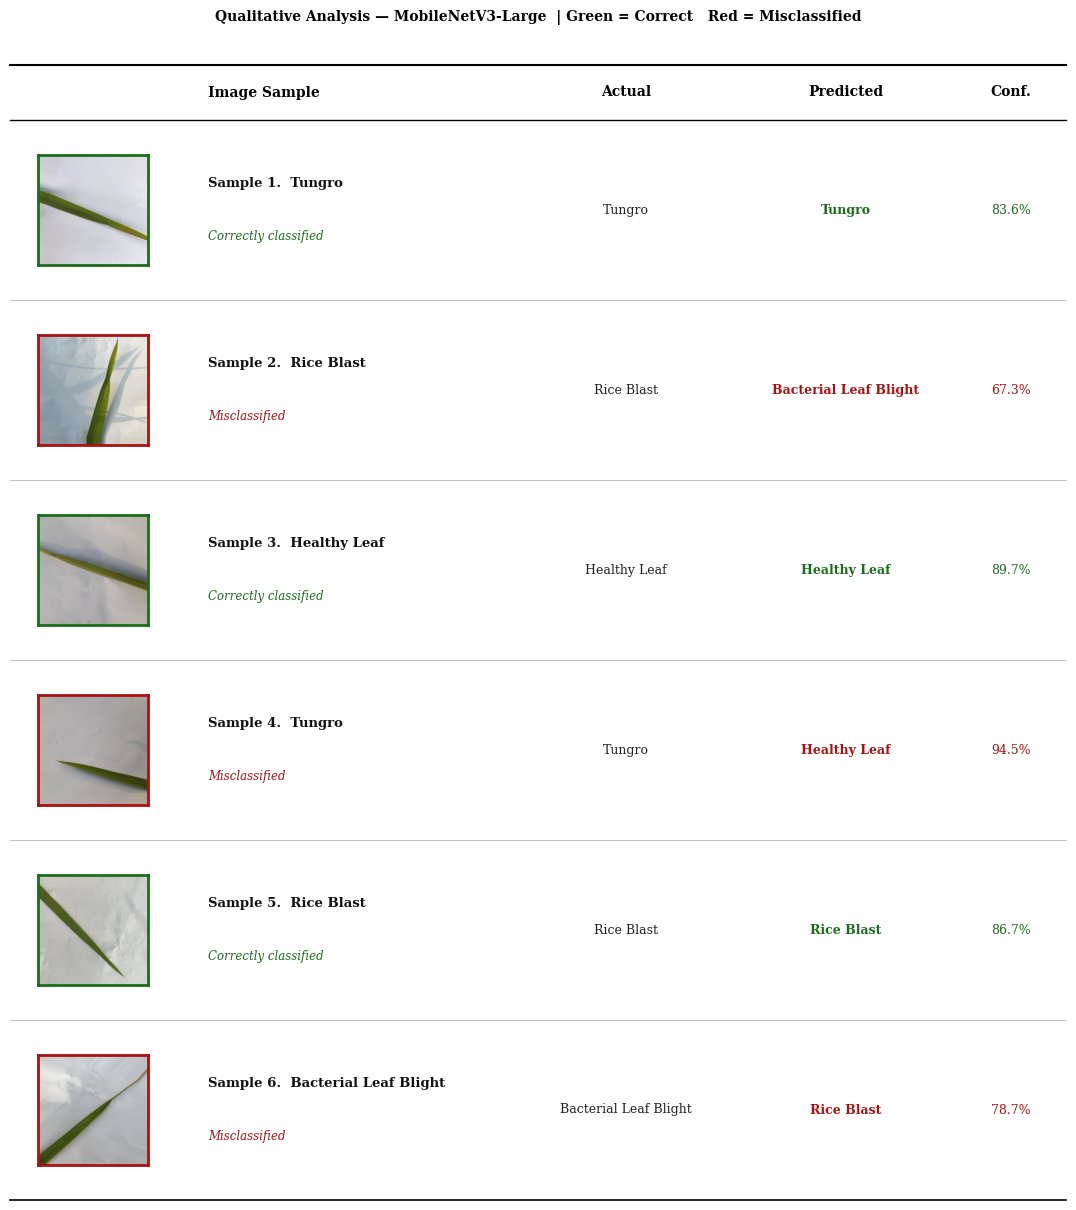

In [ ]:
# ── Qualitative Analysis — Publication Table Style
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import torch

mpl.rcParams['font.family'] = 'DejaVu Serif'

inv_mean = np.array([0.485, 0.456, 0.406])
inv_std  = np.array([0.229, 0.224, 0.225])

def denormalize(t):
    img = t.permute(1, 2, 0).cpu().numpy()
    return np.clip(img * inv_std + inv_mean, 0, 1)

label_map = {
    "Bacterial Leaf Blight": "Bacterial Leaf Blight",
    "Healthy _leaf":         "Healthy Leaf",
    "Rice Blast":            "Rice Blast",
    "Tungro":                "Tungro",
}

# ── best_model 
best_name  = max(all_model_metrics, key=lambda k: all_model_metrics[k]["accuracy"])
best_model = all_models[best_name]
print(f"Best model: {best_name}")

# ── Sample collection
best_model.eval()
correct_samples, incorrect_samples = [], []
seen_correct, seen_incorrect = set(), set()

with torch.no_grad():
    for idx in range(len(test_ds)):
        img, label = test_ds[idx]
        out = best_model(img.unsqueeze(0).to(device))
        if out.dim() == 4: out = out.mean(dim=[2,3])
        if out.dim() != 2: out = out.view(out.size(0), -1)
        prob = torch.softmax(out, dim=1)
        pred = out.argmax(1).item()
        conf = prob.max().item()

        if pred == label and label not in seen_correct and len(correct_samples) < 3:
            correct_samples.append((img.cpu(), label, pred, conf))
            seen_correct.add(label)
        elif pred != label and label not in seen_incorrect and len(incorrect_samples) < 3:
            incorrect_samples.append((img.cpu(), label, pred, conf))
            seen_incorrect.add(label)

        if len(correct_samples) >= 3 and len(incorrect_samples) >= 3:
            break

print(f"Correct: {len(correct_samples)} | Incorrect: {len(incorrect_samples)}")

# ── Interleave
chosen = []
for pair in zip(correct_samples, incorrect_samples):
    chosen.extend(pair)
if len(chosen) < 4:
    chosen = correct_samples + incorrect_samples
chosen = chosen[:6]
n = len(chosen)

# ── Layout
ROW_H        = 1.8
FIG_H        = ROW_H * n + 1.2
TOP_MARGIN   = 0.9
HEADER_H     = 0.55
IMG_H_IN     = 1.1
IMG_W_FRAC   = 0.13

col_img    = 0.03
col_desc   = 0.20
col_actual = 0.58
col_pred   = 0.78
col_conf   = 0.93

fig = plt.figure(figsize=(11, FIG_H), facecolor='white')

def yf(inches): return 1.0 - inches / FIG_H

# top rule
fig.add_artist(plt.Line2D([0.02,0.98],[yf(TOP_MARGIN)]*2,
    transform=fig.transFigure, color='black', linewidth=1.5))

# header
hy = yf(TOP_MARGIN + HEADER_H * 0.5)
for col, txt, ha in [
    (col_desc,   "Image Sample", 'left'),
    (col_actual, "Actual",       'center'),
    (col_pred,   "Predicted",    'center'),
    (col_conf,   "Conf.",        'center'),
]:
    fig.text(col, hy, txt, fontsize=10, fontweight='bold',
             ha=ha, va='center', transform=fig.transFigure)

# header rule
fig.add_artist(plt.Line2D([0.02,0.98],[yf(TOP_MARGIN+HEADER_H)]*2,
    transform=fig.transFigure, color='black', linewidth=1.0))

# rows
for ri, (img, actual, pred, conf) in enumerate(chosen):
    rtop   = TOP_MARGIN + HEADER_H + ri * ROW_H
    rcen   = rtop + ROW_H * 0.5
    rbot   = rtop + ROW_H
    rcen_f = yf(rcen)

    actual_name = label_map.get(class_names[actual], class_names[actual])
    pred_name   = label_map.get(class_names[pred],   class_names[pred])
    ok          = (actual == pred)
    clr         = '#1a6e1a' if ok else '#aa1111'

    # image
    ih_frac = IMG_H_IN / FIG_H
    ax_img  = fig.add_axes([col_img, yf(rcen + IMG_H_IN*0.5), IMG_W_FRAC, ih_frac])
    ax_img.imshow(denormalize(img))
    ax_img.set_xticks([]); ax_img.set_yticks([])
    for sp in ax_img.spines.values():
        sp.set_visible(True); sp.set_edgecolor(clr); sp.set_linewidth(2.0)

    # text
    fig.text(col_desc, rcen_f + 0.022,
             f"Sample {ri+1}.  {class_names[actual].replace('Healthy _leaf','Healthy Leaf')}",
             fontsize=9.5, fontweight='bold', ha='left', va='center',
             transform=fig.transFigure, color='#111111')
    fig.text(col_desc, rcen_f - 0.022,
             "Correctly classified" if ok else "Misclassified",
             fontsize=8.5, ha='left', va='center', style='italic',
             transform=fig.transFigure, color=clr)
    fig.text(col_actual, rcen_f, actual_name,
             fontsize=9, ha='center', va='center',
             transform=fig.transFigure, color='#222222')
    fig.text(col_pred, rcen_f, pred_name,
             fontsize=9, ha='center', va='center', fontweight='bold',
             transform=fig.transFigure, color=clr)
    fig.text(col_conf, rcen_f, f"{conf:.1%}",
             fontsize=9, ha='center', va='center',
             transform=fig.transFigure, color=clr)

    # row separator
    lw = 1.2 if ri == n-1 else 0.5
    cs = 'black' if ri == n-1 else '#aaaaaa'
    fig.add_artist(plt.Line2D([0.02,0.98],[yf(rbot)]*2,
        transform=fig.transFigure, color=cs, linewidth=lw))

fig.suptitle(
    f"Qualitative Analysis — {best_name}  "
    "| Green = Correct   Red = Misclassified",
    fontsize=10, fontweight='bold', y=yf(0.35)
)
plt.subplots_adjust(top=1, bottom=0, left=0, right=1)

save_path = os.path.join(OUT_DIR, "plots", "qualitative_table_publication")
os.makedirs(os.path.dirname(save_path), exist_ok=True)
fig.savefig(save_path + ".png", dpi=300, bbox_inches="tight")
fig.savefig(save_path + ".pdf",           bbox_inches="tight")
print(f"✅ Saved -> {save_path}.png / .pdf")
plt.show()

Model: Swin-Tiny
Correct: 3 | Incorrect: 3
✅ Saved -> /kaggle/working/paper_outputs/plots/qualitative_table_swin_tiny.png / .pdf


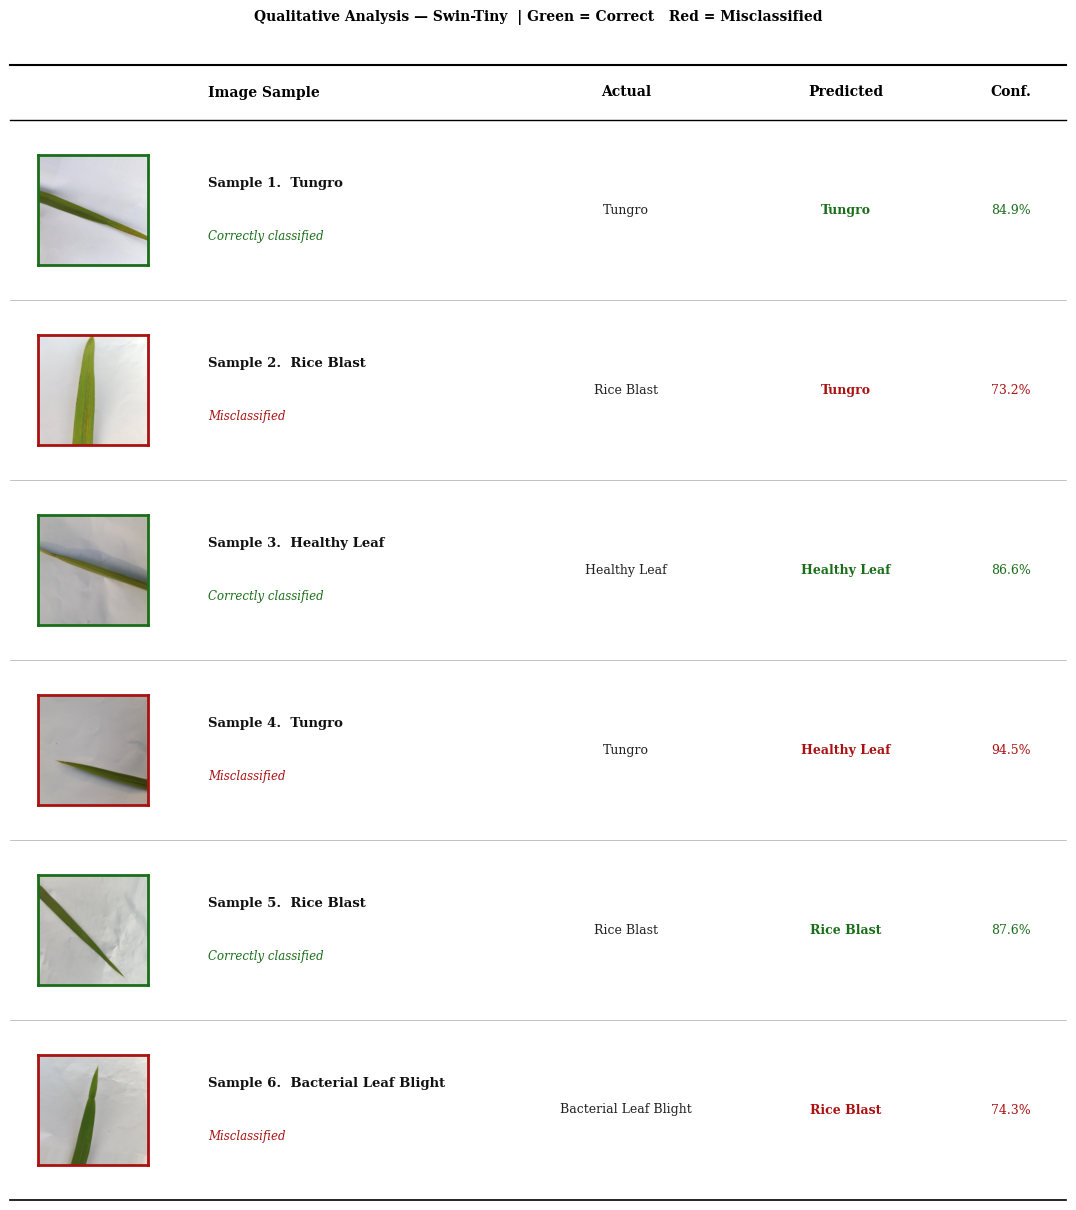

In [32]:
# ── Qualitative Analysis — Swin-Tiny ──
swin_name  = "Swin-Tiny"
swin_model = all_models[swin_name]
print(f"Model: {swin_name}")

# ── Sample collection
swin_model.eval()
correct_samples, incorrect_samples = [], []
seen_correct, seen_incorrect = set(), set()

with torch.no_grad():
    for idx in range(len(test_ds)):
        img, label = test_ds[idx]
        out = swin_model(img.unsqueeze(0).to(device))
        if out.dim() == 4: out = out.mean(dim=[2,3])
        if out.dim() != 2: out = out.view(out.size(0), -1)
        prob = torch.softmax(out, dim=1)
        pred = out.argmax(1).item()
        conf = prob.max().item()

        if pred == label and label not in seen_correct and len(correct_samples) < 3:
            correct_samples.append((img.cpu(), label, pred, conf))
            seen_correct.add(label)
        elif pred != label and label not in seen_incorrect and len(incorrect_samples) < 3:
            incorrect_samples.append((img.cpu(), label, pred, conf))
            seen_incorrect.add(label)

        if len(correct_samples) >= 3 and len(incorrect_samples) >= 3:
            break

print(f"Correct: {len(correct_samples)} | Incorrect: {len(incorrect_samples)}")

# ── Interleave
chosen = []
for pair in zip(correct_samples, incorrect_samples):
    chosen.extend(pair)
if len(chosen) < 4:
    chosen = correct_samples + incorrect_samples
chosen = chosen[:6]
n = len(chosen)

# ── Layout
ROW_H        = 1.8
FIG_H        = ROW_H * n + 1.2
TOP_MARGIN   = 0.9
HEADER_H     = 0.55
IMG_H_IN     = 1.1
IMG_W_FRAC   = 0.13

col_img    = 0.03
col_desc   = 0.20
col_actual = 0.58
col_pred   = 0.78
col_conf   = 0.93

fig = plt.figure(figsize=(11, FIG_H), facecolor='white')

def yf(inches): return 1.0 - inches / FIG_H

fig.add_artist(plt.Line2D([0.02,0.98],[yf(TOP_MARGIN)]*2,
    transform=fig.transFigure, color='black', linewidth=1.5))

hy = yf(TOP_MARGIN + HEADER_H * 0.5)
for col, txt, ha in [
    (col_desc,   "Image Sample", 'left'),
    (col_actual, "Actual",       'center'),
    (col_pred,   "Predicted",    'center'),
    (col_conf,   "Conf.",        'center'),
]:
    fig.text(col, hy, txt, fontsize=10, fontweight='bold',
             ha=ha, va='center', transform=fig.transFigure)

fig.add_artist(plt.Line2D([0.02,0.98],[yf(TOP_MARGIN+HEADER_H)]*2,
    transform=fig.transFigure, color='black', linewidth=1.0))

for ri, (img, actual, pred, conf) in enumerate(chosen):
    rtop   = TOP_MARGIN + HEADER_H + ri * ROW_H
    rcen   = rtop + ROW_H * 0.5
    rbot   = rtop + ROW_H
    rcen_f = yf(rcen)

    actual_name = label_map.get(class_names[actual], class_names[actual])
    pred_name   = label_map.get(class_names[pred],   class_names[pred])
    ok          = (actual == pred)
    clr         = '#1a6e1a' if ok else '#aa1111'

    ih_frac = IMG_H_IN / FIG_H
    ax_img  = fig.add_axes([col_img, yf(rcen + IMG_H_IN*0.5), IMG_W_FRAC, ih_frac])
    ax_img.imshow(denormalize(img))
    ax_img.set_xticks([]); ax_img.set_yticks([])
    for sp in ax_img.spines.values():
        sp.set_visible(True); sp.set_edgecolor(clr); sp.set_linewidth(2.0)

    fig.text(col_desc, rcen_f + 0.022,
             f"Sample {ri+1}.  {class_names[actual].replace('Healthy _leaf','Healthy Leaf')}",
             fontsize=9.5, fontweight='bold', ha='left', va='center',
             transform=fig.transFigure, color='#111111')
    fig.text(col_desc, rcen_f - 0.022,
             "Correctly classified" if ok else "Misclassified",
             fontsize=8.5, ha='left', va='center', style='italic',
             transform=fig.transFigure, color=clr)
    fig.text(col_actual, rcen_f, actual_name,
             fontsize=9, ha='center', va='center',
             transform=fig.transFigure, color='#222222')
    fig.text(col_pred, rcen_f, pred_name,
             fontsize=9, ha='center', va='center', fontweight='bold',
             transform=fig.transFigure, color=clr)
    fig.text(col_conf, rcen_f, f"{conf:.1%}",
             fontsize=9, ha='center', va='center',
             transform=fig.transFigure, color=clr)

    lw = 1.2 if ri == n-1 else 0.5
    cs = 'black' if ri == n-1 else '#aaaaaa'
    fig.add_artist(plt.Line2D([0.02,0.98],[yf(rbot)]*2,
        transform=fig.transFigure, color=cs, linewidth=lw))

fig.suptitle(
    f"Qualitative Analysis — {swin_name}  "
    "| Green = Correct   Red = Misclassified",
    fontsize=10, fontweight='bold', y=yf(0.35)
)
plt.subplots_adjust(top=1, bottom=0, left=0, right=1)

save_path = os.path.join(OUT_DIR, "plots", "qualitative_table_swin_tiny")
os.makedirs(os.path.dirname(save_path), exist_ok=True)
fig.savefig(save_path + ".png", dpi=300, bbox_inches="tight")
fig.savefig(save_path + ".pdf",           bbox_inches="tight")
print(f"✅ Saved -> {save_path}.png / .pdf")
plt.show()

In [ ]:
# ── Verify all outputs saved as both PNG + PDF
import glob, os
from PIL import Image

dirs = [
    os.path.join(OUT_DIR, "plots"),
    os.path.join(OUT_DIR, "gradcam"),
]

print("📁 Converting any missing PDFs...\n")
converted = 0
for d in dirs:
    for png in glob.glob(os.path.join(d, "*.png")):
        pdf = png.replace(".png", ".pdf")
        if not os.path.exists(pdf):
            Image.open(png).convert("RGB").save(pdf, "PDF", resolution=300)
            print(f"  Converted: {os.path.basename(pdf)}")
            converted += 1

if converted == 0:
    print("  ✅ all files saved in pdf।")

print("\n📋 Final output list:")
print(f"{'File':<55} {'KB':>8}")
print("-" * 65)
for d in dirs:
    for f in sorted(glob.glob(os.path.join(d, "*"))):
        kb = os.path.getsize(f) / 1024
        print(f"  {os.path.relpath(f, OUT_DIR):<53} {kb:>7.1f}")

📁 Converting any missing PDFs...

  ✅ সব files এর PDF আগেই আছে।

📋 Final output list:
File                                                          KB
-----------------------------------------------------------------
  plots/all_loss_curves.pdf                                32.4
  plots/all_loss_curves.png                               582.9
  plots/confusion_matrix_best_MobileNetV3-Large.pdf        32.9
  plots/confusion_matrix_best_MobileNetV3-Large.png       117.0
  plots/latency_all_models.pdf                             23.1
  plots/latency_all_models.png                            166.7
  plots/qualitative_table_publication.pdf                 108.4
  plots/qualitative_table_publication.png                 805.5
  plots/summary_table_publication.pdf                      24.0
  plots/summary_table_publication.png                     153.0
  gradcam/gradcam_best_MobileNetV3-Large.pdf              398.1
  gradcam/gradcam_best_MobileNetV3-Large.png              722.4
